In [4]:
import pandas as pd


FILE_PATH = r"C:\Users\seohyun\Downloads\부산소재_고등교육기관_졸업자_취업통계_2024.xlsx"

df = pd.read_excel(FILE_PATH, sheet_name="부산_전체")
df.shape

(2170, 94)

In [5]:
# 대학 + 교육대학 + 전문대학만 필터링 (대학원 제외)
target_types = ["대학", "교육대학", "전문대학"]
target = df[df["학제"].isin(target_types)].copy()

print("필터링 전 행 수:", len(df))
print("필터링 후 행 수:", len(target))
print("포함된 학제:", target["학제"].unique())

필터링 전 행 수: 2170
필터링 후 행 수: 1139
포함된 학제: ['대학' '교육대학' '전문대학']


In [7]:
# 대계열도 참고용으로 같이 보고 싶다면
by_daegye = (
    target.groupby("대계열")
    .agg(졸업자_수=("졸업자_계", "sum"))
    .reset_index()
)
by_daegye["졸업자_비율(%)"] = (by_daegye["졸업자_수"] / by_daegye["졸업자_수"].sum() * 100).round(2)
by_daegye.sort_values("졸업자_비율(%)", ascending=False).reset_index(drop=True)

,대계열,졸업자_수,졸업자_비율(%)
0,사회계열,10033,27.12
1,공학계열,9917,26.81
2,예체능계열,4390,11.87
3,의약계열,4281,11.57
4,자연계열,3470,9.38
5,인문계열,3312,8.95
6,교육계열,1593,4.31


In [6]:
# 중계열별 졸업자 수 & 학과(행) 수 집계
summary = (
    target.groupby("중계열")
    .agg(
        졸업자_수=("졸업자_계", "sum"),
        학과_수=("학과명", "count"),
        학교_수=("학교명", "nunique"),
    )
    .reset_index()
)

# 비율(%) 계산
total_grads = summary["졸업자_수"].sum()
summary["졸업자_비율(%)"] = (summary["졸업자_수"] / total_grads * 100).round(2)

# 비율 높은 순으로 정렬
summary = summary.sort_values("졸업자_비율(%)", ascending=False).reset_index(drop=True)

print(f"전체 졸업자 수: {total_grads:,}명")
summary

전체 졸업자 수: 36,996명


,중계열,졸업자_수,학과_수,학교_수,졸업자_비율(%)
0,경영ㆍ경제,6074,163,19,16.42
1,사회과학,3731,112,20,10.08
2,언어ㆍ문학,2093,75,14,5.66
3,치료ㆍ보건,1950,58,16,5.27
4,컴퓨터ㆍ통신,1917,60,16,5.18
5,기계ㆍ금속,1864,41,12,5.04
6,간호,1793,17,16,4.85
7,전기ㆍ전자,1632,33,13,4.41
8,생물ㆍ화학ㆍ환경,1594,59,14,4.31
9,생활과학,1249,44,16,3.38


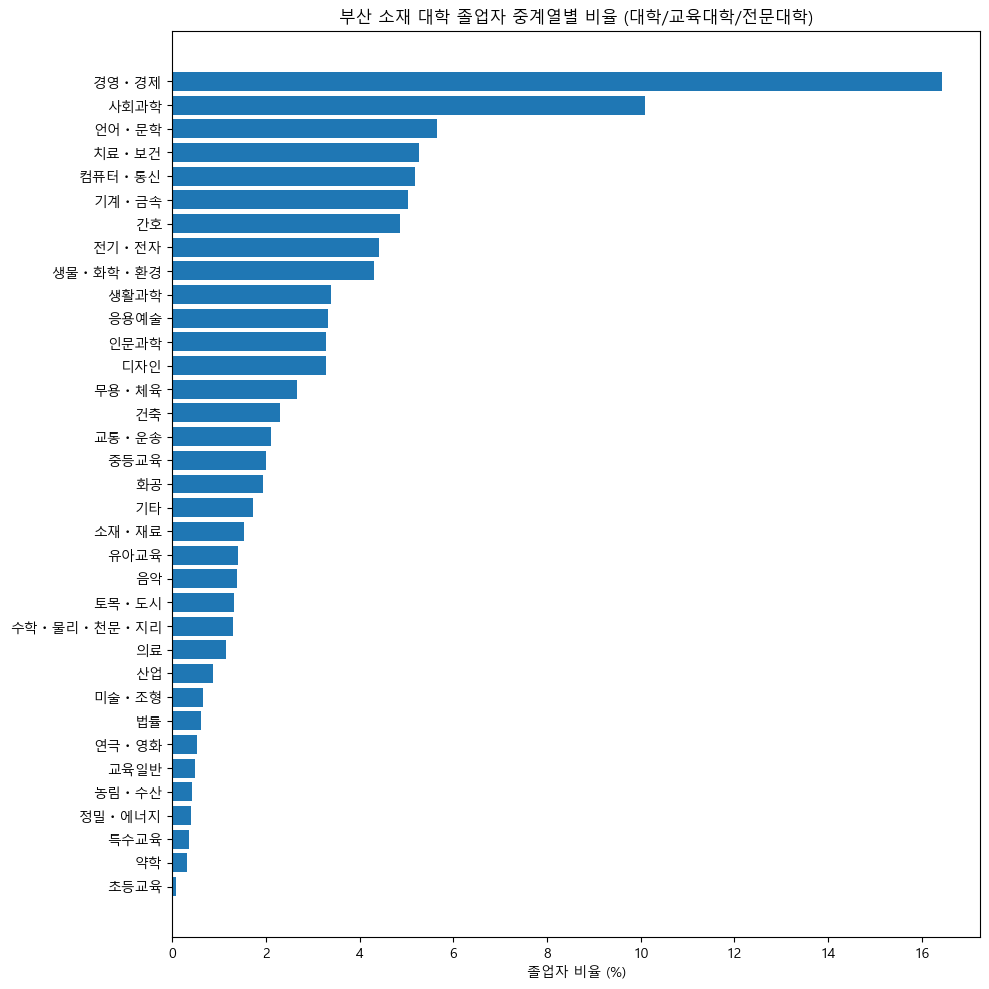

In [13]:
# 막대그래프로 시각화 (중계열별 졸업자 비율)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows용 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 10))
plot_df = summary.sort_values("졸업자_비율(%)")
ax.barh(plot_df["중계열"], plot_df["졸업자_비율(%)"])
ax.set_xlabel("졸업자 비율 (%)")
ax.set_title("부산 소재 대학 졸업자 중계열별 비율 (대학/교육대학/전문대학)")
plt.tight_layout()
plt.show()

In [9]:
# 중계열 → 그룹계열 매핑
group_map = {
    '경영ㆍ경제': '경영·사무',
    '사회과학': '경영·사무',
    '법률': '경영·사무',
    '산업': '경영·사무',
    '언어ㆍ문학': '인문·어학',
    '인문과학': '인문·어학',
    '컴퓨터ㆍ통신': 'IT·컴퓨터',
    '전기ㆍ전자': '기계·전기전자',
    '기계ㆍ금속': '기계·전기전자',
    '소재ㆍ재료': '기계·전기전자',
    '정밀ㆍ에너지': '기계·전기전자',
    '화공': '기계·전기전자',
    '건축': '건설·토목',
    '토목ㆍ도시': '건설·토목',
    '디자인': '디자인·예술',
    '응용예술': '디자인·예술',
    '미술ㆍ조형': '디자인·예술',
    '연극ㆍ영화': '디자인·예술',
    '음악': '디자인·예술',
    '무용ㆍ체육': '디자인·예술',
    '치료ㆍ보건': '보건·의료',
    '간호': '보건·의료',
    '의료': '보건·의료',
    '약학': '보건·의료',
    '생활과학': '생활과학·화학',
    '생물ㆍ화학ㆍ환경': '생활과학·화학',
    '수학ㆍ물리ㆍ천문ㆍ지리': '자연과학',
    '교육일반': '교육',
    '유아교육': '교육',
    '초등교육': '교육',
    '중등교육': '교육',
    '특수교육': '교육',
    '교통ㆍ운송': '물류·운송',
    '농림ㆍ수산': '농림·수산',
    '기타': '기타',
}

# 새 컬럼으로 그룹계열 추가
target['그룹계열'] = target['중계열'].map(group_map)

# 혹시 매핑 안 된 중계열이 있는지 확인 (있으면 여기 뜸)
unmapped = target[target['그룹계열'].isna()]['중계열'].unique()
if len(unmapped) > 0:
    print("⚠️ 매핑 안 된 중계열:", unmapped)
else:
    print("모든 중계열이 매핑되었습니다.")

모든 중계열이 매핑되었습니다.


In [10]:
# 그룹계열별 집계
summary_grouped = (
    target.groupby('그룹계열')
    .agg(
        졸업자_수=('졸업자_계', 'sum'),
        중계열_수=('중계열', 'nunique'),
        학과_수=('학과명', 'count'),
        학교_수=('학교명', 'nunique'),
    )
    .reset_index()
)

total = summary_grouped['졸업자_수'].sum()
summary_grouped['졸업자_비율(%)'] = (summary_grouped['졸업자_수'] / total * 100).round(2)
summary_grouped = summary_grouped.sort_values('졸업자_비율(%)', ascending=False).reset_index(drop=True)

summary_grouped

,그룹계열,졸업자_수,중계열_수,학과_수,학교_수,졸업자_비율(%)
0,경영·사무,10350,4,294,20,27.98
1,기계·전기전자,4927,5,122,14,13.32
2,디자인·예술,4390,6,175,20,11.87
3,보건·의료,4281,4,85,19,11.57
4,인문·어학,3312,2,122,18,8.95
5,생활과학·화학,2843,2,103,19,7.68
6,IT·컴퓨터,1917,1,60,16,5.18
7,교육,1593,5,71,16,4.31
8,건설·토목,1335,2,44,12,3.61
9,물류·운송,781,1,20,8,2.11


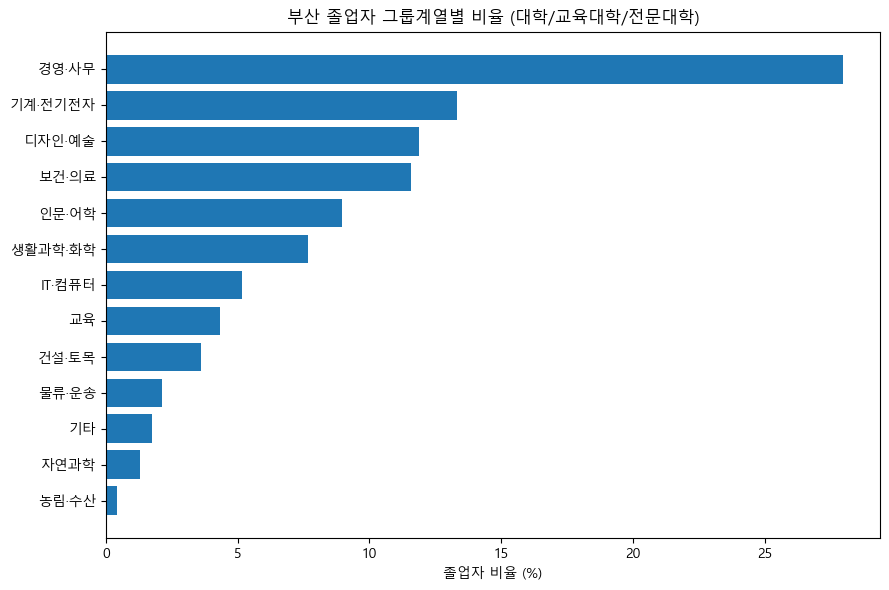

In [11]:
# 그래프로 확인
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = summary_grouped.sort_values('졸업자_비율(%)')
ax.barh(plot_df['그룹계열'], plot_df['졸업자_비율(%)'])
ax.set_xlabel('졸업자 비율 (%)')
ax.set_title('부산 졸업자 그룹계열별 비율 (대학/교육대학/전문대학)')
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

FILE_PATH = r"C:\Users\seohyun\Downloads\부산소재_고등교육기관_졸업자_취업통계_2024.xlsx"

df = pd.read_excel(FILE_PATH, sheet_name="부산_전체")

# 일반대학(4년제)만 필터링
target = df[df["학제"] == "대학"].copy()

print("전체 행 수:", len(df))
print("일반대학만 필터링 후 행 수:", len(target))
print("학교 수:", target["학교명"].nunique())
target["학교명"].unique()

전체 행 수: 2170
일반대학만 필터링 후 행 수: 855
학교 수: 13


array(['경성대학교', '고신대학교', '국립부경대학교', '국립한국해양대학교', '동명대학교', '동서대학교',
       '동아대학교', '동의대학교', '부산가톨릭대학교', '부산대학교', '부산외국어대학교', '신라대학교',
       '영산대학교'], dtype=object)

In [15]:
# 중계열별 졸업자 수 & 비율 집계
summary = (
    target.groupby("중계열")
    .agg(
        졸업자_수=("졸업자_계", "sum"),
        학과_수=("학과명", "count"),
        학교_수=("학교명", "nunique"),
    )
    .reset_index()
)

total_grads = summary["졸업자_수"].sum()
summary["졸업자_비율(%)"] = (summary["졸업자_수"] / total_grads * 100).round(2)
summary = summary.sort_values("졸업자_비율(%)", ascending=False).reset_index(drop=True)

print(f"일반대학 전체 졸업자 수: {total_grads:,}명")
summary

일반대학 전체 졸업자 수: 28,640명


,중계열,졸업자_수,학과_수,학교_수,졸업자_비율(%)
0,경영ㆍ경제,5472,129,13,19.11
1,사회과학,2560,78,13,8.94
2,언어ㆍ문학,2042,67,11,7.13
3,컴퓨터ㆍ통신,1739,50,12,6.07
4,생물ㆍ화학ㆍ환경,1444,54,10,5.04
5,기계ㆍ금속,1361,26,9,4.75
6,전기ㆍ전자,1227,23,10,4.28
7,인문과학,1126,44,12,3.93
8,디자인,947,43,10,3.31
9,간호,836,11,10,2.92


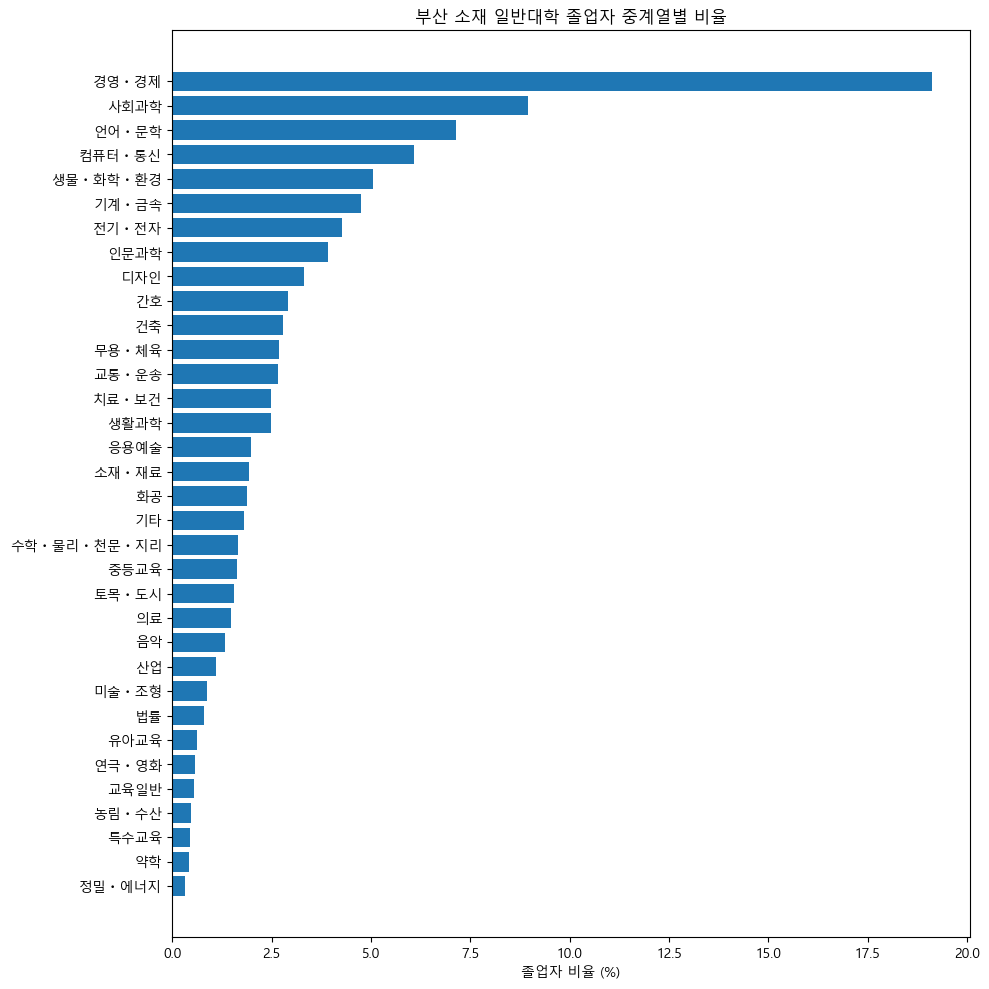

In [16]:
# 막대그래프 시각화
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 10))
plot_df = summary.sort_values("졸업자_비율(%)")
ax.barh(plot_df["중계열"], plot_df["졸업자_비율(%)"])
ax.set_xlabel("졸업자 비율 (%)")
ax.set_title("부산 소재 일반대학 졸업자 중계열별 비율")
plt.tight_layout()
plt.show()

In [17]:
# 중계열 → 그룹계열 매핑
group_map = {
    '경영ㆍ경제': '경영·사무',
    '사회과학': '경영·사무',
    '법률': '경영·사무',
    '산업': '경영·사무',
    '언어ㆍ문학': '인문·어학',
    '인문과학': '인문·어학',
    '컴퓨터ㆍ통신': 'IT·컴퓨터',
    '전기ㆍ전자': '기계·전기전자',
    '기계ㆍ금속': '기계·전기전자',
    '소재ㆍ재료': '기계·전기전자',
    '정밀ㆍ에너지': '기계·전기전자',
    '화공': '기계·전기전자',
    '건축': '건설·토목',
    '토목ㆍ도시': '건설·토목',
    '디자인': '디자인·예술',
    '응용예술': '디자인·예술',
    '미술ㆍ조형': '디자인·예술',
    '연극ㆍ영화': '디자인·예술',
    '음악': '디자인·예술',
    '무용ㆍ체육': '디자인·예술',
    '치료ㆍ보건': '보건·의료',
    '간호': '보건·의료',
    '의료': '보건·의료',
    '약학': '보건·의료',
    '생활과학': '생활과학·화학',
    '생물ㆍ화학ㆍ환경': '생활과학·화학',
    '수학ㆍ물리ㆍ천문ㆍ지리': '자연과학',
    '교육일반': '교육',
    '유아교육': '교육',
    '초등교육': '교육',
    '중등교육': '교육',
    '특수교육': '교육',
    '교통ㆍ운송': '물류·운송',
    '농림ㆍ수산': '농림·수산',
    '기타': '기타',
}

# 그룹계열 컬럼 추가
target['그룹계열'] = target['중계열'].map(group_map)

unmapped = target[target['그룹계열'].isna()]['중계열'].unique()
if len(unmapped) > 0:
    print("⚠️ 매핑 안 된 중계열:", unmapped)
else:
    print("모든 중계열이 매핑되었습니다.")

모든 중계열이 매핑되었습니다.


In [18]:
# 그룹계열별 집계
summary_grouped = (
    target.groupby('그룹계열')
    .agg(
        졸업자_수=('졸업자_계', 'sum'),
        중계열_수=('중계열', 'nunique'),
        학과_수=('학과명', 'count'),
        학교_수=('학교명', 'nunique'),
    )
    .reset_index()
)

total = summary_grouped['졸업자_수'].sum()
summary_grouped['졸업자_비율(%)'] = (summary_grouped['졸업자_수'] / total * 100).round(2)
summary_grouped = summary_grouped.sort_values('졸업자_비율(%)', ascending=False).reset_index(drop=True)

summary_grouped

,그룹계열,졸업자_수,중계열_수,학과_수,학교_수,졸업자_비율(%)
0,경영·사무,8577,4,226,13,29.95
1,기계·전기전자,3775,5,90,10,13.18
2,인문·어학,3168,2,111,13,11.06
3,디자인·예술,3080,6,121,12,10.75
4,생활과학·화학,2153,2,79,12,7.52
5,보건·의료,2087,4,39,11,7.29
6,IT·컴퓨터,1739,1,50,12,6.07
7,건설·토목,1241,2,40,9,4.33
8,교육,934,4,44,9,3.26
9,물류·운송,759,1,19,7,2.65


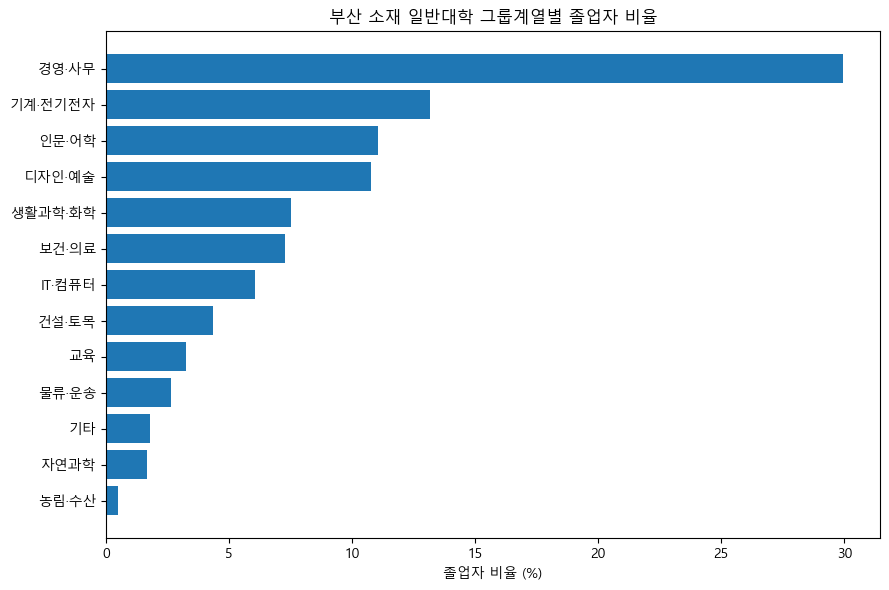

In [19]:
# 그래프
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = summary_grouped.sort_values('졸업자_비율(%)')
ax.barh(plot_df['그룹계열'], plot_df['졸업자_비율(%)'])
ax.set_xlabel('졸업자 비율 (%)')
ax.set_title('부산 소재 일반대학 그룹계열별 졸업자 비율')
plt.tight_layout()
plt.show()

In [20]:
summary_grouped.to_csv("부산_일반대학_그룹계열별_비율.csv", index=False, encoding="utf-8-sig")

In [21]:
import os
print(os.getcwd())

C:\Users\seohyun
